In [12]:
from raytrace2 import RayTrace
import numpy as np
from scipy.optimize import minimize

In [13]:
def func(a, b):
    rt = RayTrace(no_of_rays=5)
    rt.surface("source", rad_curv=np.inf, thickness=10, ref_idx=1, dia=5)
    rt.surface("front", rad_curv=20, thickness=5, ref_idx=1.5, dia=15)
    rt.surface("back", rad_curv=-50, thickness=a, ref_idx=1.0, dia=15)
    rt.surface("front", rad_curv=20, thickness=b, ref_idx=1.5, dia=22)
    rt.surface("back", rad_curv=-20, thickness=40, ref_idx=1.0, dia=22)

    x_ray, y_ray, theta_ray = rt.trace()
    #rt.show_trace()

    return rt.get_EFFL(x_ray, y_ray, theta_ray)

# Expected value
EFFL_act = 30.0

# Define RMS loss function
def rms_loss(params):
    a,b = params
    y_exp = func(a,b)
    rms = np.sqrt((y_exp - EFFL_act)**2)  # For single value, sqrt((y_exp - y_act)^2) = |y_exp - y_act|
    return rms

In [14]:
# Initial guess for parameters
initial_guess = [50,5]

# Run optimization
result = minimize(rms_loss, initial_guess, method='Powell')

# Optimized parameters
optimized_params = result.x
optimized_value = func(*optimized_params)

print("Optimized parameters:", optimized_params)
print("Function value with optimized parameters:", optimized_value)
print("RMS error:", rms_loss(optimized_params))

Optimized parameters: [88.74005258  4.65893576]
Function value with optimized parameters: 30.0
RMS error: 0.0


EFFL = 30.0 mm


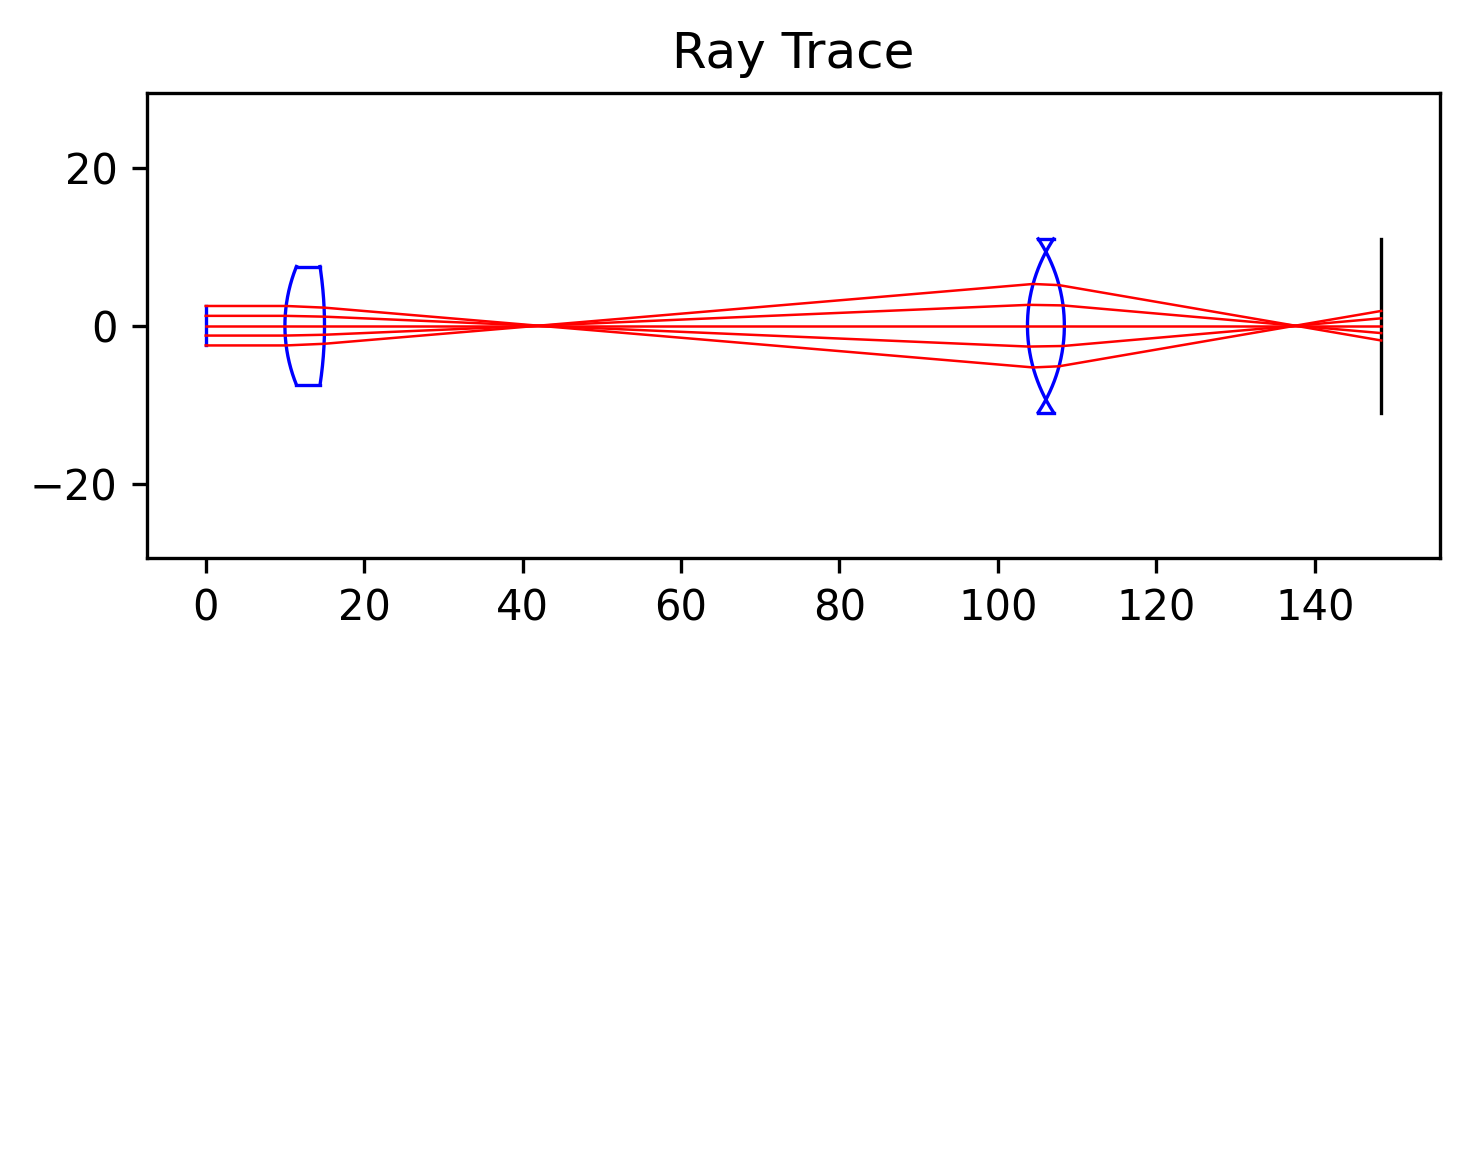

In [15]:
a,b = optimized_params
rt = RayTrace(no_of_rays=5)
rt.surface("source", rad_curv=np.inf, thickness=10, ref_idx=1, dia=5)
rt.surface("front", rad_curv=20, thickness=5, ref_idx=1.5, dia=15)
rt.surface("back", rad_curv=-50, thickness=a, ref_idx=1.0, dia=15)
rt.surface("front", rad_curv=20, thickness=b, ref_idx=1.5, dia=22)
rt.surface("back", rad_curv=-20, thickness=40, ref_idx=1.0, dia=22)

x_ray, y_ray, theta_ray = rt.trace()
print(f"EFFL = {rt.get_EFFL(x_ray, y_ray, theta_ray)} mm")
rt.show_trace()